# E-commerce Sales Analysis

## Business Context

E-commerce platforms generate large volumes of transactional data on a daily basis. Understanding this data is essential for improving business performance, optimizing product offerings, and enhancing customer experience.

In this project, we analyze histrical sales data from an online retail business to uncover patternsin sales, customer behavior, and product performance.

## Objective

The main objectives of this analysis are:
- Analyze overall sales trends over time
- Identify top-performing and underperforming products
- Explore customer purchasing behavior
- Examine sales distribution across different countries
- Generate actionable business insights

## Dataset

This dataset consists of transactional data from an online retail business, capturing customer purchases, product information, pricing, and temoral sales patterns.

## Data Inspection

**Goal:**
Understand the structure of the dataset.

**Steps:**
- Load dataset into pandas DataFrame
- Inspect first rows
- Check column types and missing values
- Generate summary statistics

In [1]:
# Import library pandas
import pandas as pd

In [2]:
# Install openpyxl in the current kernel enviroment
import sys #引入python系统模块(System)
!{sys.executable} -m pip install openpyxl #{sys.executable}把python路径插入到命令里,-m用python运行一个模块,pip是python的管理工具(App store)


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip


In [3]:
import os #引入操作系统模块(Operating System),以接触电脑文件系统

#os.getcwd() = get curent working directory返回当前工作目录，即当前所在位置
os.listdir("../data") #os.listdir()列出当前目录下所有文件和文件夹, os.listdir("../data")查看上一级data文件夹, .DS_Store是系统隐藏文件, ..上一级, ../..上两级

['.DS_Store', 'online_retail_II.xlsx']

In [4]:
#查看.gitignore是否在30Day-Reboot文件里
os.getcwd()#我在哪儿
os.listdir("../..")

['.Rhistory',
 'ecommerce_sales_analysis',
 'restaurant_tips_analysis',
 '.gitignore',
 '.ipynb_checkpoints',
 'Git命令拆解.pages',
 '.git']

#在Notebook创建/更新根目录下黑名单(.gitignore)

import os
#根目录路径(Notebook在ecommerce_sales_analysis/notebook)
gitignore_path = "../../.gitignore"

#内容
gitignore_content = """ #"""为python多行字符串
# macOS
.DS_Store #系统文件

# Python
__pycache__/ #python缓存
*.pyc

#Jupyter
.ipynb_checkpoints/ #Jupyter检查点

#R
.Rhistory

# Logs
*.log #日志

# VS Code settings
.vscode/ #编辑器

.pages

# 写入文件
with open(gitignore_path, "w") as f: #w模式=若已存在.gitignore就覆盖, f=文件对象(打开的文件)
    f.write(gitignore_content.strip()) #strip()去掉首尾空行

print(".gitignore 已经创建/更新在:", gitignore_path)

# 追加文件内容

with open(gitignore_path, "r") as f: #r=读取
    content = f.read() #f.read()把文件全部读出来

if "*.log" not in content:
    with open(gitignore_path, "a") as f: #a模式=append在末尾追加
    f.write("\n*.log.strip()\n") #\n自动换行

print("Content appended to .gitignore")

os.listdir("../") #检查黑名单是否出现在根目录

In [5]:
gitignore_path = "../../.gitignore"

new_content = """
.DS_Store
__pycache__/
*.pyc
.ipynb_checkpoints/
.vscode/
"""

with open(gitignore_path, "r") as f:
    content = f.read()

if new_content.strip() not in content:
    with open(gitignore_path, "a") as f:
        f.write("\n" + new_content.strip() + "\n")

print("New content appended to .gitignore")

New content appended to .gitignore


In [6]:
# Load dataset
df = pd.read_excel("../data/online_retail_II.xlsx", sheet_name="Year 2010-2011")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
df.describe

<bound method NDFrame.describe of        Invoice StockCode                          Description  Quantity  \
0       536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1       536365     71053                  WHITE METAL LANTERN         6   
2       536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3       536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4       536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...        ...       ...                                  ...       ...   
541905  581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906  581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907  581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908  581587     22138        BAKING SET 9 PIECE RETROSPOT          3   
541909  581587      POST                              POSTAGE         1   

               InvoiceDate  Price  Customer ID         Country  


In [9]:
## Data Cleaning

#Check out negative numbers (Refund)
(df["Quantity"] < 0).sum()

np.int64(10624)

In [10]:
df[df["Quantity"] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [11]:
#Save positive data as sales and negative data as returns
df_sales = df[df["Quantity"] > 0].copy() #copy.()创建独立数据副本，避免“连带修改”
df_returns = df[df["Quantity"] < 0].copy()

In [12]:
df_sales.shape

(531286, 8)

In [13]:
sum = 531286+10624
print(sum)

541910


There are 10624 rows of nagative quantities which invoice IDs begin with "C". This indicates product returns or cancellations, so I excluded them to focus on actual sales transactions. I preserved the original dataset and created separate subsets for sales and returns to enable flexible analysis.

In [14]:
# Check missing values in column "Customer ID"
df_sales["Customer ID"].isnull().sum()

np.int64(133361)

In [15]:
# Remove the missing value from column "Customer ID"
df_sales = df_sales.dropna(subset=["Customer ID"]).copy() #subset为dropna参数，只检查指定列是否有缺失值

In [16]:
df_sales["Customer ID"].isnull().sum()

np.int64(0)

133361 missing values were in the column "Customer ID". I removed these records to ensure the dataset is suitable for customer-level analysis.

In [17]:
# Convert InvoiceDate from string to datetime for time-based analysis
df_sales["InvoiceDate"] = pd.to_datetime(df_sales["InvoiceDate"]) #pd.to_datetime()将时间字符串转换成时间格式

In [18]:
## Monthly Sales Trend

#df_sales["YearMonth"] = df_sales["InvoiceDate"].dt.to_period("M") #dt.为pandas时间处理工具，to_period("M")把时间转换成按月的时间单位且同月份不同年也会被正确分组
#monthly_sales = df_sales.groupby("YearMonth")["TotalPrice"].sum() #groupby("YeearMonth")数据按月份分组，其中"TotalPrice"这一列在每个分组内求和

# Create sales
df_sales["TotalPrice"] = df_sales["Quantity"] * df_sales["Price"]

monthly_sales = df_sales.resample("ME", on="InvoiceDate")["TotalPrice"].sum()
monthly_sales.head()

InvoiceDate
2010-12-31    572713.890
2011-01-31    569445.040
2011-02-28    447137.350
2011-03-31    595500.760
2011-04-30    469200.361
Freq: ME, Name: TotalPrice, dtype: float64

In [19]:
## Visualization

# Import library seaborn
import seaborn as sns
import matplotlib.pyplot as plt

图表已保存为 monthly_sales.png


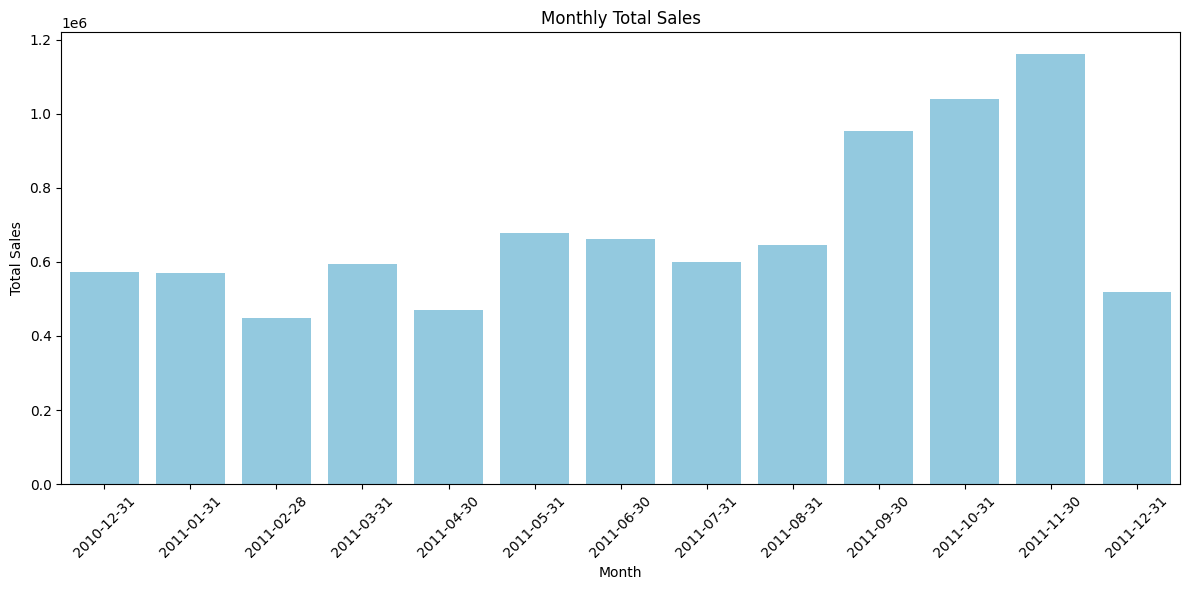

In [20]:
#Barplot InvoiceDate vs TotalPrice
monthly_sales_df = monthly_sales.reset_index() #把索引变成列

plt.figure(figsize=(12, 6))
sns.barplot(x="InvoiceDate", y="TotalPrice", data=monthly_sales_df, color="skyblue")
plt.xticks(rotation=45)
plt.title("Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.tight_layout()
#plt.show()

plt.savefig("monthly_sales.png")
print("图表已保存为 monthly_sales.png")